In [19]:
using CoordinateTransformations
using Images
using ImageView
using TestImages

In [3]:
IMG_DIR = "../images"

"../images"

┌ Info: Recompiling stale cache file /Users/dsp/.julia/compiled/v1.0/QuartzImageIO/n8vDP.ji for QuartzImageIO [dca85d43-d64c-5e67-8c65-017450d5d020]
└ @ Base loading.jl:1184


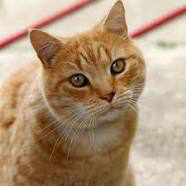

In [4]:
img_path = "$IMG_DIR/cat.jpg"
sample_image = nothing

if isfile(img_path)
    sample_image = load(img_path)
else
    println("ERROR: Image not found")
end

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 54030  100 54030    0     0  24500      0  0:00:02  0:00:02 --:--:-- 42243


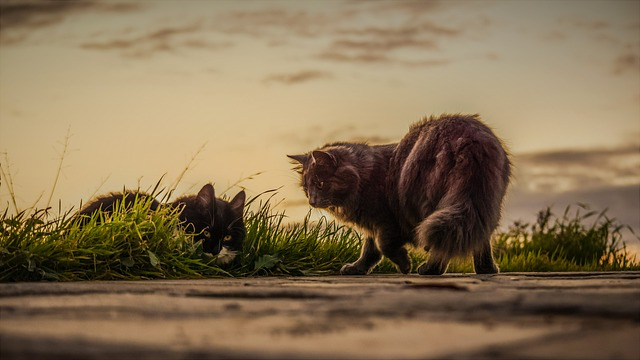

In [5]:
image_url = ("https://cdn.pixabay.com/photo/2018/01/04/18/58/"
             * "cats-3061372_640.jpg?attachment")
download_path = download(image_url, "$IMG_DIR/cat_download.jpg")
image = load(download_path)

In [6]:
image_files = readdir(IMG_DIR)
images = filter(x -> occursin(r"\.(jpe?g|png|gif){1}$"i, x), image_files)

for image_name in images
  image_path = joinpath(IMG_DIR, image_name)
  image = load(image_path)
end

In [7]:
img = load(img_path)
save("$IMG_DIR/cat_copy.jpg", img)
save("$IMG_DIR/cat_copy2.png", img)

In [9]:
img = testimage("mandril_color")
save("$IMG_DIR/mandril_color.png")

#19 (generic function with 1 method)

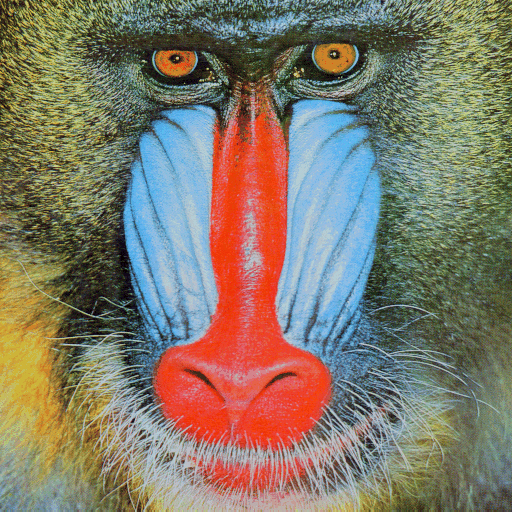

In [10]:
img

In [13]:
img = load("$IMG_DIR/cat.jpg")
#imshow(img) # (attempts to) open in plotting device

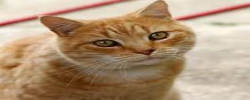

In [14]:
resized_img = imresize(img, (100, 250))
resized_img

In [15]:
source_image = load("$IMG_DIR/cat_download.jpg")
size(source_image)

(360, 640)

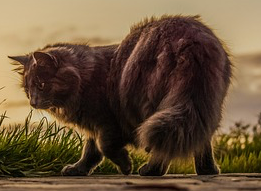

In [16]:
cropped_image = source_image[100:290, 280:540]
cropped_image

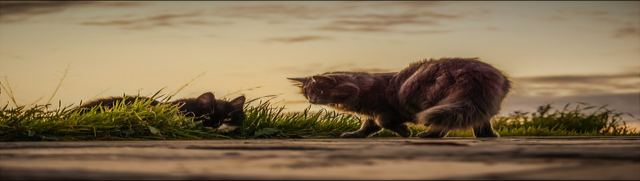

In [17]:
resized_image = restrict(source_image, 1) # 1 = height: halves
resized_image

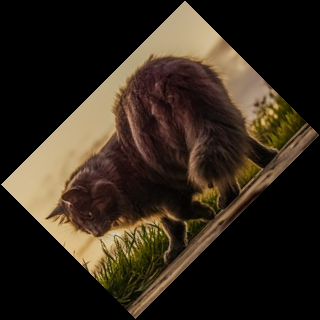

In [21]:
transformation = LinearMap(RotMatrix(-pi / 4))
img = warp(cropped_image, transformation)
img